In [56]:
import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd
from glob import glob
import scipy.stats
import seaborn as sns
from matplotlib import pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import PrecisionRecallDisplay, precision_score, recall_score, roc_auc_score

## Combine data

In [2]:
eco_ts_objects = [
    xr.open_dataset(f) for f in
    glob("../data_working/lcms/eco_timeseries/*.nc")
]

s1_ts_objects = [
    xr.open_dataset(f) for f in
    glob("../data_working/lcms/s1_timeseries/*.nc")
]

ndvi_ts_objects = [
    xr.open_dataset(f) for f in 
    glob("../data_working/lcms/ndvi_timeseries/*.nc")
]

In [3]:
# Convert each sensor type into a melted dataframe
eco_concat   = pd.concat([obj.to_dataframe() for obj in eco_ts_objects])\
    .drop(columns=["QC", "spatial_ref", "cloud", "tmin", "tmax"])
s1_concat    = pd.concat([obj.to_dataframe() for obj in s1_ts_objects])\
    .drop(columns=["spatial_ref", "tmin", "tmax"])
ndvi_concat  = pd.concat([obj.to_dataframe() for obj in ndvi_ts_objects])\
    .drop(columns=["spatial_ref", "ndvi300_qflag"])\
    .rename_axis(index={'geometry': 'sample'})

In [4]:
all_sensors_melt = pd.concat([
    eco_concat.melt(ignore_index=False).dropna(subset=["value"]),
    s1_concat.melt(ignore_index=False).dropna(subset=["value"]),
    ndvi_concat.melt(ignore_index=False).dropna(subset=["value"])
])

In [5]:
all_sensors_melt

variable     value
sample time                              
697    2018-09-02           ESI  0.916855
       2018-09-03           ESI  0.881421
       2018-09-06           ESI  0.812139
       2019-06-04           ESI  0.876636
       2019-06-15           ESI  0.855922
...                         ...       ...
12777  2026-05-11  ndvi300_ndvi  0.204000
       2026-05-21  ndvi300_ndvi  0.340000
       2026-06-01  ndvi300_ndvi  0.476000
       2026-06-11  ndvi300_ndvi  0.496000
       2026-06-21  ndvi300_ndvi  0.576000

[25340118 rows x 2 columns]

In [6]:
# Attach mort/non-mort classification for each row
detections = gpd.read_file("../data_working/detections.parquet")
detections["mort_group"] = np.where(detections.tmin == -1, "non-mort", "mort")

all_sensors_melt = all_sensors_melt.join(detections.drop(columns=["geometry", "severity"]), on="sample")

In [7]:
# Attach a reference year from the nearest mort for each non-mort
detections_mort = detections[(detections.tmin != -1) & (detections.severity >= 5)]
detections_nonmort = detections[detections.tmin == -1]

nonmort_paired_mort = gpd.sjoin_nearest(
    detections_nonmort,
    detections_mort.drop(columns=["tmax", "severity"]),
    lsuffix=""
)

nonmort_paired_mort = nonmort_paired_mort[~nonmort_paired_mort.index.duplicated(keep='first')]\
    .drop(columns=["tmin_", "tmax", "severity", "geometry", "mort_group_", "mort_group_right"])\
    .rename(columns=dict(tmin_right="paired_mort_tmin", index_right="paired_mort_sample"))

all_sensors_melt = all_sensors_melt.join(nonmort_paired_mort, on="sample")

In [8]:
all_sensors_melt

variable     value  tmin  tmax mort_group  \
sample time                                                        
697    2018-09-02           ESI  0.916855  2007  2009       mort   
       2018-09-03           ESI  0.881421  2007  2009       mort   
       2018-09-06           ESI  0.812139  2007  2009       mort   
       2019-06-04           ESI  0.876636  2007  2009       mort   
       2019-06-15           ESI  0.855922  2007  2009       mort   
...                         ...       ...   ...   ...        ...   
12777  2026-05-11  ndvi300_ndvi  0.204000    -1    -1   non-mort   
       2026-05-21  ndvi300_ndvi  0.340000    -1    -1   non-mort   
       2026-06-01  ndvi300_ndvi  0.476000    -1    -1   non-mort   
       2026-06-11  ndvi300_ndvi  0.496000    -1    -1   non-mort   
       2026-06-21  ndvi300_ndvi  0.576000    -1    -1   non-mort   

                   paired_mort_sample  paired_mort_tmin  
sample time                                              
697    2018-09-02                 NaN               NaN  
       2018-09-03                 NaN               NaN  
       2018-09-06                 NaN               NaN  
       2019-06-04                 NaN               NaN  
       2019-06-15                 NaN               NaN  
...                               ...               ...  
12777  2026-05-11              5586.0            2019.0  
       2026-05-21              5586.0            2019.0  
       2026-06-01              5586.0            2019.0  
       2026-06-11              5586.0            2019.0  
       2026-06-21              5586.0            2019.0  

[25340118 rows x 7 columns]

In [9]:
# Get growing season for each geom/year
severity = detections.severity
severity.index.set_names(["geometry"], inplace=True)
growing_season = pd.read_parquet("../data_working/detections_phenology.parquet")
growing_season = growing_season.join(severity, how="inner").drop(columns="severity")
growing_season["sos_doy"] = growing_season["lsp300_sosd_s1"]
growing_season["eos_doy"] = np.fmin(growing_season["lsp300_eosd_s1"], growing_season["lsp300_eosd_s2"])
growing_season = growing_season[["sos_doy", "eos_doy"]]
growing_season = growing_season.reset_index()

In [10]:
all_sensors_melt["obs_year"] = all_sensors_melt.index.get_level_values("time").year
all_sensors_melt["obs_doy"] = all_sensors_melt.index.get_level_values("time").dayofyear
all_sensors_melt = all_sensors_melt.reset_index()

In [11]:
all_sensors_melt = pd.merge(
    all_sensors_melt,
    growing_season,
    left_on=[all_sensors_melt["sample"], all_sensors_melt.obs_year],
    right_on=[growing_season["geometry"], growing_season["time"].dt.year]
)

In [12]:
# Drop observations outside growing season
all_sensors_filter = all_sensors_melt[
    (all_sensors_melt.obs_doy >= all_sensors_melt.sos_doy) &
    (all_sensors_melt.obs_doy <= all_sensors_melt.eos_doy)
].drop(columns=["key_0", "key_1", "time_y"]).rename(columns=dict(time_x="time"))

In [13]:
all_sensors_filter

,sample,time,variable,value,tmin,tmax,mort_group,paired_mort_sample,paired_mort_tmin,obs_year,obs_doy,geometry,sos_doy,eos_doy
4,697,2019-06-15,ESI,0.855922,2007,2009,mort,NaN,NaN,2019,166,697,157.0,258.5
5,697,2019-06-20,ESI,0.711734,2007,2009,mort,NaN,NaN,2019,171,697,157.0,258.5
6,697,2019-06-23,ESI,0.694401,2007,2009,mort,NaN,NaN,2019,174,697,157.0,258.5
7,697,2019-08-20,ESI,0.944835,2007,2009,mort,NaN,NaN,2019,232,697,157.0,258.5
8,697,2019-08-21,ESI,0.956210,2007,2009,mort,NaN,NaN,2019,233,697,157.0,258.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24297614,12777,2025-08-01,ndvi300_ndvi,0.660000,-1,-1,non-mort,5586.0,2019.0,2025,213,12777,157.0,261.0
24297615,12777,2025-08-11,ndvi300_ndvi,0.636000,-1,-1,non-mort,5586.0,2019.0,2025,223,12777,157.0,261.0
24297616,12777,2025-08-21,ndvi300_ndvi,0.576000,-1,-1,non-mort,5586.0,2019.0,2025,233,12777,157.0,261.0
24297617,12777,2025-09-01,ndvi300_ndvi,0.432000,-1,-1,non-mort,5586.0,2019.0,2025,244,12777,157.0,261.0


In [14]:
# Aggregate annual mean of NDVI, ESI, and VH backscatter
conditional_tmin = np.where(
    all_sensors_filter.tmin == -1, 
    all_sensors_filter.paired_mort_tmin, 
    all_sensors_filter.tmin
)

all_sensors_filter["obs_year_rel"] = all_sensors_filter["obs_year"] - conditional_tmin

In [15]:
ann_summary = all_sensors_filter[all_sensors_filter.variable.isin(["ESI", "ndvi300_ndvi", "VH"])]\
    .groupby(["geometry", "obs_year_rel", "variable"]).agg({
    "value": "mean",
    "mort_group": lambda x: x.iloc[0]
})

In [16]:
ann_summary

value mort_group
geometry obs_year_rel variable                            
0        -10.0        ndvi300_ndvi     0.825026       mort
         -9.0         VH               0.048409       mort
                      ndvi300_ndvi     0.823445       mort
         -8.0         VH           -6553.561035       mort
                      ndvi300_ndvi     0.827795       mort
...                                         ...        ...
13005     22.0        VH               0.036032   non-mort
                      ndvi300_ndvi     0.597000   non-mort
          23.0        ESI              0.748821   non-mort
                      VH               0.033913   non-mort
                      ndvi300_ndvi     0.596667   non-mort

[277314 rows x 2 columns]

In [17]:
# silence small sample warnings from theilsen
import warnings
warnings.filterwarnings("ignore", message=".*sample arguments is too small.*")
warnings.filterwarnings("ignore", message=".*mean of empty slice.*")

In [18]:
# Apply transformations 
# Convert SAR backscatter to DB. This conveniently nans a few
# bad observations with a fill value.
VH_sigma0 = ann_summary.loc[pd.IndexSlice[:, :, "VH"], "value"]
VH_sigma0_db = 10 * np.log10(VH_sigma0)
ann_summary.loc[pd.IndexSlice[:, :, "VH"], "value"] = VH_sigma0_db

/srv/conda/envs/notebook/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [19]:
# Standardize SAR backscatter and NDVI to account for cover being a
# confounding variable between mort and non-mort groups
def robust_std(x: pd.Series):
    '''
    Standardize `x` as (x - median(x)) / IQR.
    '''
    return (x - x.median()) / (x.quantile(0.75) - x.quantile(0.25))

for var in ["VH", "ndvi300_ndvi"]:
    x = ann_summary.loc[pd.IndexSlice[:, :, var], "value"]
    x_std = x.groupby("geometry", group_keys=False).apply(lambda x: (x - x.mean()) / x.std())
    to_append = pd.DataFrame({
        "value": x_std.reset_index(drop=True),
        "mort_group": ann_summary.loc[pd.IndexSlice[:, :, var], "mort_group"].reset_index(drop=True)
    }).set_index(x.rename(index={var:var+"_std"}).index)
    ann_summary = pd.concat([ann_summary, to_append])

In [20]:
ann_summary = ann_summary.sort_index()

In [21]:
nonmort_paired_mort

,paired_mort_sample,paired_mort_tmin
6503,6031,2023
6504,4748,2017
6505,6265,2012
6506,6092,2020
6507,5392,2016
...,...,...
13001,5230,2020
13002,2854,2017
13003,159,2019
13004,1714,2023


Paired t-test at mortality onset

In [22]:
def paired_sample_ttest(var: str, **ttest_kwargs):
    # Get values for non-mortality pixels at event onset for a given variable
    nonmort_at_onset = ann_summary.loc[:, 0, var].query("mort_group == 'non-mort'")
    
    # Look up the corresponding nearest mortality geometry
    nonmort_at_onset["mort_geom"] = nonmort_paired_mort["paired_mort_sample"].loc[
        nonmort_at_onset.index.get_level_values("geometry")
    ]
    
    # Attach the value from the mortality geometry to the non-mort geometry
    paired_value = pd.merge(
        nonmort_at_onset,
        ann_summary.loc[:, 0, var].query("mort_group == 'mort'"),
        how="inner",
        left_on="mort_geom",
        right_on="geometry"
    )
    
    # Run paired sample t-test. "value_x" is the NON-MORT sample
    return paired_value, scipy.stats.ttest_rel(paired_value["value_x"], paired_value["value_y"], **ttest_kwargs)

TtestResult(statistic=12.073422121708882, pvalue=2.8583513862510543e-32, df=1372)
ConfidenceInterval(low=0.026460291868311777, high=inf)


Text(0.5, 0, 'Mort - non-mort difference')

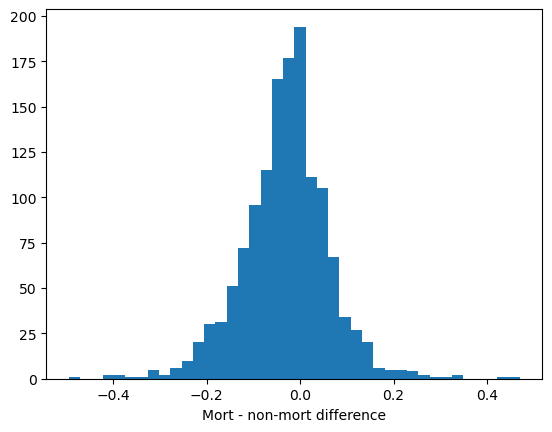

In [54]:
paired, test = paired_sample_ttest("ESI", nan_policy="omit", alternative="greater")
print(test)
print(test.confidence_interval())
plt.hist(paired["value_y"] - paired["value_x"], bins=40)
plt.xlabel("Mort - non-mort difference")

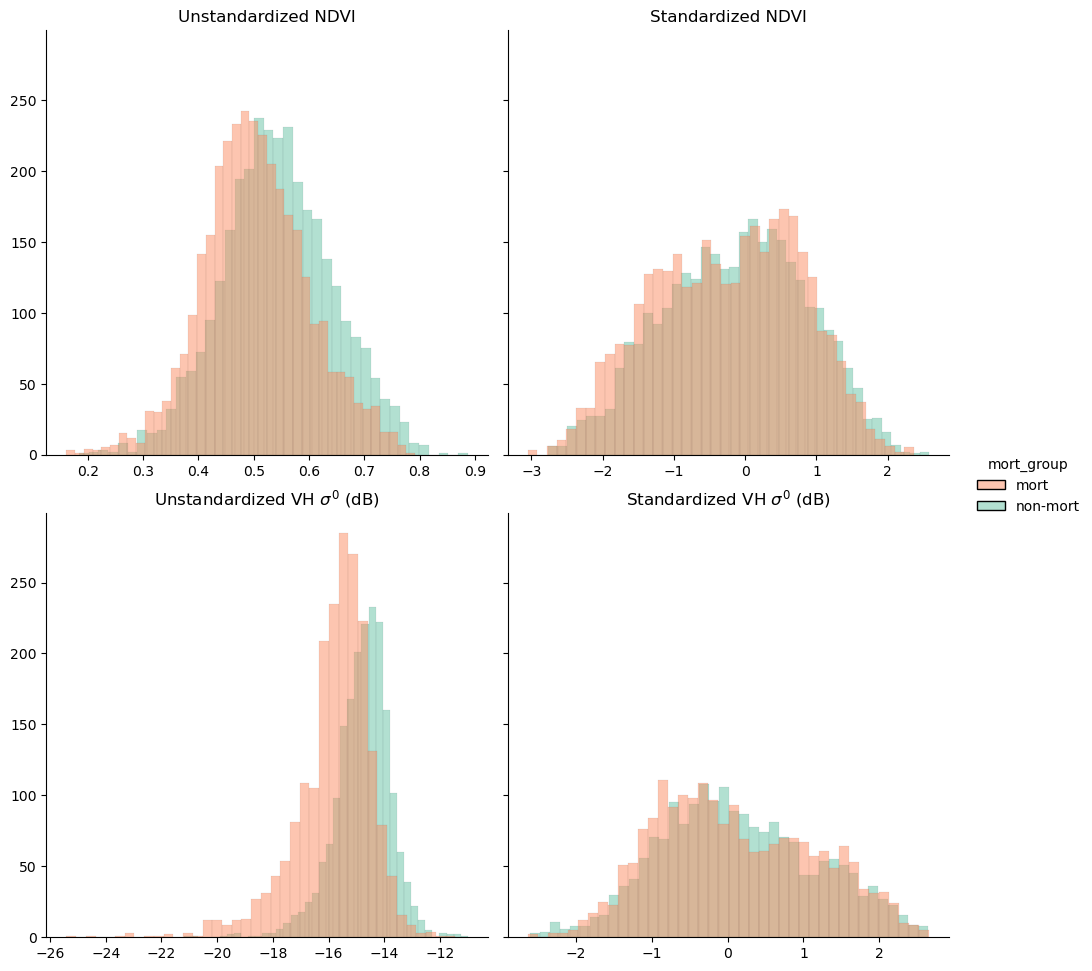

In [24]:
facet = sns.displot(
    data=ann_summary.loc[:, 0, ["ndvi300_ndvi", "ndvi300_ndvi_std", "VH", "VH_std"]], 
    x='value',
    hue="mort_group",
    col='variable', kind='hist', col_wrap=2,
    common_bins=False,
    bins=40,
    facet_kws=dict(sharex=False),
    palette={"mort":"#fc8d62", "non-mort":"#66c2a5"} 
)

plt.gcf().supxlabel("")
facet.set_axis_labels("", "")
facet.axes.flat[0].set_title("Unstandardized NDVI")
facet.axes.flat[1].set_title("Standardized NDVI")
facet.axes.flat[2].set_title("Unstandardized VH $\\sigma^0$ (dB)")
facet.axes.flat[3].set_title("Standardized VH $\\sigma^0$ (dB)")
plt.show()

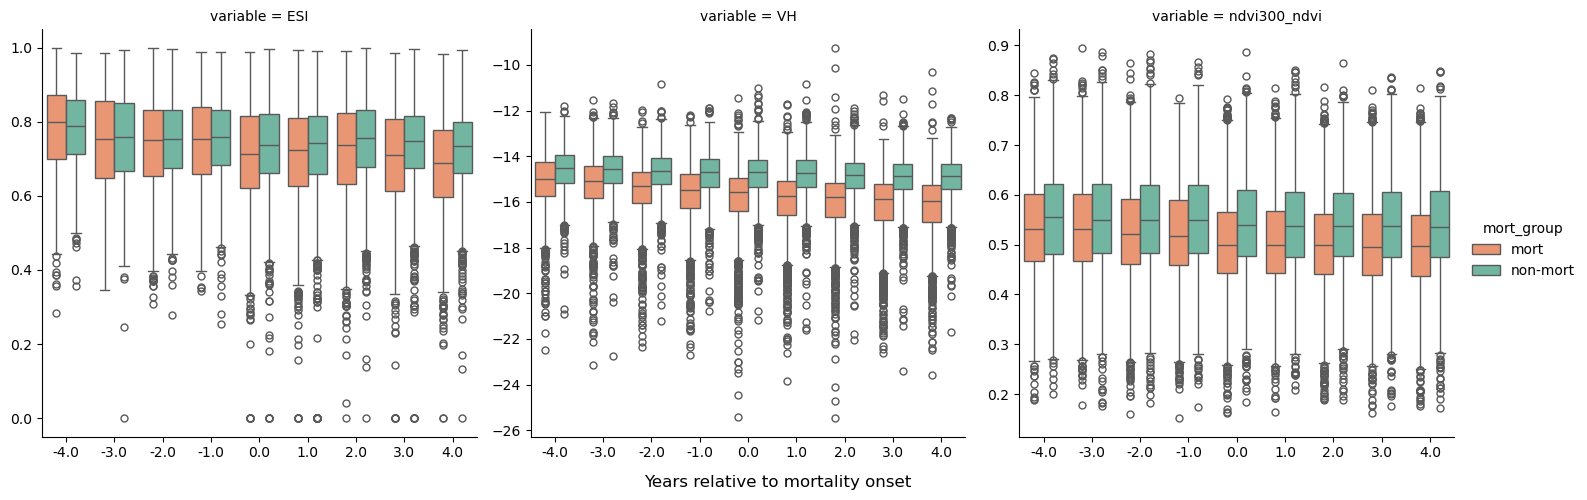

In [25]:
facet = sns.catplot(
    data=ann_summary.loc[:, slice(-4, 4), ["ndvi300_ndvi", "VH", "ESI"]], 
    x='obs_year_rel', y='value',
    hue="mort_group",
    sharex=True, sharey=False,
    col='variable', kind='box', col_wrap=3,
    palette={"mort":"#fc8d62", "non-mort":"#66c2a5"} 
)

plt.gcf().supxlabel("Years relative to mortality onset")
facet.set_axis_labels("", "")
#facet.axes[0].set_title("Standardized VH backscatter (dB)")
#facet.axes[1].set_title("Standardized NDVI")
plt.show()

In [26]:
# Run linear regressions - do we see change about mortality onset?
for var in ["ndvi300_ndvi", "VH", "ESI"]:
    print(var)
    subset = ann_summary.loc[:, slice(-4, 4), var]
    
    for group, data in subset.groupby("mort_group"):
        data = data.dropna()
        mod = sm.OLS(data["value"], data.index.get_level_values("obs_year_rel")).fit()
        print(group)
        print(mod.f_pvalue)
        print(mod.params)
        print(mod.conf_int())

ndvi300_ndvi
mort
1.2598117249694899e-120
x1    0.028953
dtype: float64
           0         1
x1  0.026535  0.031372
non-mort
4.7717109789511924e-135
x1    0.033925
dtype: float64
           0         1
x1  0.031253  0.036598
VH
mort
0.0
x1   -1.868894
dtype: float64
           0         1
x1 -1.963776 -1.774011
non-mort
3.4367317067715242e-276
x1   -1.683095
dtype: float64
           0         1
x1 -1.774102 -1.592088
ESI
mort
0.0
x1    0.099587
dtype: float64
           0         1
x1  0.095112  0.104062
non-mort
0.0
x1    0.107937
dtype: float64
           0         1
x1  0.103275  0.112599


In [47]:
for var in ["ndvi300_ndvi", "VH", "ESI"]:
    diff = ann_summary.loc[:, [-3, 3], var]\
        .rename(index={-3:"premort", 3:"postmort"})\
        .reset_index(level="obs_year_rel")\
        .pivot(columns="obs_year_rel", values="value")
    
    diff["change"] = diff["postmort"] - diff["premort"]

    print(var)
    print((diff["change"] < 0).value_counts())
    print(scipy.stats.ttest_1samp(diff["change"], 0, alternative="less", nan_policy="omit"))

ndvi300_ndvi
change
False    5129
True     2751
Name: count, dtype: int64
TtestResult(statistic=-31.854152581028675, pvalue=1.1712875414581276e-197, df=3763)
VH
change
False    4060
True     1157
Name: count, dtype: int64
TtestResult(statistic=-26.530116933098114, pvalue=4.156407162872613e-128, df=1523)
ESI
change
False    4716
True      664
Name: count, dtype: int64
TtestResult(statistic=-27.630279761506287, pvalue=4.285798794212069e-118, df=782)


ndvi300_ndvi_std
6566
Precision: 0.521
Recall: 0.683
AUC: 0.507
VH_std
3965
Precision: 0.510
Recall: 0.859
AUC: 0.499
ESI
3077
Precision: 0.535
Recall: 0.593
AUC: 0.529


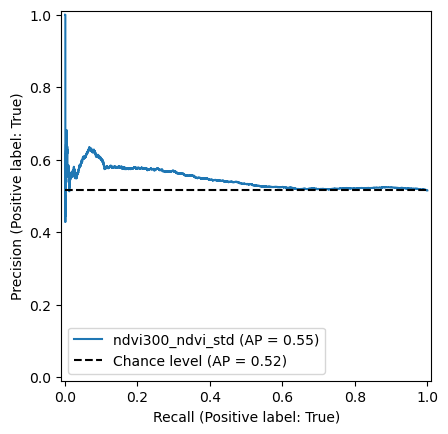

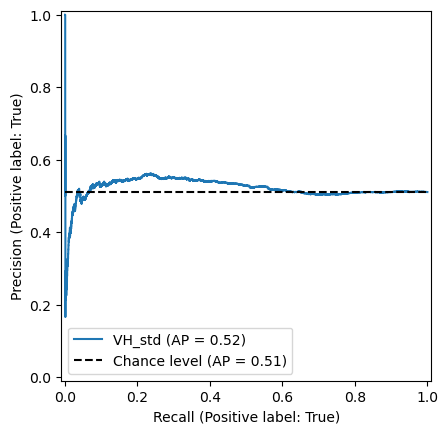

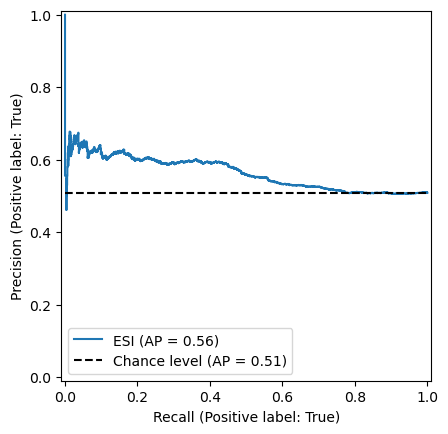

In [58]:
for var in ["ndvi300_ndvi_std", "VH_std", "ESI"]:
    subset = ann_summary.loc[:, 0, var].dropna()
    
    y = subset["mort_group"] == "mort"
    x = subset[["value"]]
    
    logreg = LogisticRegression()
    logreg.fit(x, y)
    print(var)
    print(x.shape[0])
    print(f"Precision: {precision_score(y, logreg.predict(x)):.3f}")
    print(f"Recall: {recall_score(y, logreg.predict(x)):.3f}")
    print(f"AUC: {roc_auc_score(y, logreg.predict(x)):.3f}")


    PrecisionRecallDisplay.from_estimator(logreg, x, y, plot_chance_level=True, name=var)

In [29]:
ann_summary.to_parquet("../data_working/ann_summary_lcms.parquet")

### Power spectrum analysis

In [30]:
obs_range = ann_summary.reset_index().groupby("geometry")["obs_year_rel"].agg(["min", "max"])
obs_range["range"] = obs_range["max"] - obs_range["min"]
usable_ts = obs_range[
    (obs_range["max"] >= 1) &
    (obs_range["min"] <= -1) &
    (obs_range["range"] >= 8)
]

In [31]:
usable_ndvi_ts = all_sensors_melt.set_index("sample").loc[usable_ts.index].query("variable == 'ndvi300_ndvi'")

In [32]:
usable_ndvi_ts

,key_0,key_1,time_x,variable,value,tmin,tmax,mort_group,paired_mort_sample,paired_mort_tmin,obs_year,obs_doy,geometry,time_y,sos_doy,eos_doy
geometry,,,,,,,,,,,,,,,,
0,0,2014,2014-01-01,ndvi300_ndvi,0.150000,2024,2024,mort,NaN,NaN,2014,1,0,2014-01-01,112.333336,261.666656
0,0,2014,2014-01-11,ndvi300_ndvi,0.226667,2024,2024,mort,NaN,NaN,2014,11,0,2014-01-01,112.333336,261.666656
0,0,2014,2014-01-21,ndvi300_ndvi,0.314000,2024,2024,mort,NaN,NaN,2014,21,0,2014-01-01,112.333336,261.666656
0,0,2014,2014-02-01,ndvi300_ndvi,0.288000,2024,2024,mort,NaN,NaN,2014,32,0,2014-01-01,112.333336,261.666656
0,0,2014,2014-02-11,ndvi300_ndvi,0.344000,2024,2024,mort,NaN,NaN,2014,42,0,2014-01-01,112.333336,261.666656
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13004,13004,2025,2025-10-01,ndvi300_ndvi,0.376000,-1,-1,non-mort,1714.0,2023.0,2025,274,13004,2025-01-01,157.000000,251.000000
13004,13004,2025,2025-10-11,ndvi300_ndvi,0.336000,-1,-1,non-mort,1714.0,2023.0,2025,284,13004,2025-01-01,157.000000,251.000000
13004,13004,2025,2025-10-21,ndvi300_ndvi,0.288000,-1,-1,non-mort,1714.0,2023.0,2025,294,13004,2025-01-01,157.000000,251.000000


In [33]:
from scipy.signal import detrend, spectrogram

def spectral_power(obs_time: pd.Series, value: pd.Series, mort_year: int, sample_period: int=10, **spec_kwargs):
    # Convert obs dt to days since Y2K
    zero_date = pd.to_datetime(f"{mort_year}-01-01")
    x_epoch = (obs_time - zero_date) / pd.Timedelta(days=1)
    # Detrend the timeseries
    y_detrend = detrend(value)

    # Resample to constant sample frequency
    x_new = np.arange(x_epoch.min(), x_epoch.max(), sample_period)
    y_new = np.interp(x_new, x_epoch, y_detrend)

    # Spectrogram
    sample_freq = 1/sample_period
    f, t, Sxx = spectrogram(y_new, sample_freq, nperseg=32, noverlap=16, scaling="spectrum", **spec_kwargs)
    t_asdate = zero_date + pd.to_timedelta(t + x_new.min(), unit="days")

    # Sum frequencies with period longer than 100 days
    Sxx_sum = Sxx[f < 0.01].sum(axis=0)

    return t_asdate, Sxx_sum

In [34]:
def spectral_power_driver(df: pd.DataFrame):
    mort_year = int(df.paired_mort_tmin.iloc[0]) if df.tmin.iloc[0] == -1 else df.tmin.iloc[0]
    t_asdate, smax = spectral_power(df["time_x"], df["value"], mort_year)
    smax_rel = smax / smax.max()
    
    t_rel = (t_asdate - pd.to_datetime(f"{mort_year}-01-01")) / pd.Timedelta(days=1)
    # Relative spectral power at mortality start
    smax_rel_at_mort = np.interp(0, t_rel, smax_rel)

    # Trend in spectral power leading up to mortality
    pre_mort_mask = (t_rel < 0) & (t_rel > -1500)
    if pre_mort_mask.sum() < 5:
        smax_trend_pre_mort = np.nan
    else:
        smax_trend_pre_mort = np.polyfit(t_rel[pre_mort_mask], smax_rel[pre_mort_mask], 1)[0]
    
    ret = pd.Series(dict(
        mort_group=df.mort_group.iloc[0],
        onset_year=mort_year,
        rel_smax_at_onset=smax_rel_at_mort,
        smax_trend_at_onset=smax_trend_pre_mort
    ))

    return ret

In [35]:
ndvi_power_at_onset = usable_ndvi_ts.drop(columns=["geometry"]).groupby("geometry").apply(spectral_power_driver)

<Axes: xlabel='smax_trend_at_onset', ylabel='Count'>

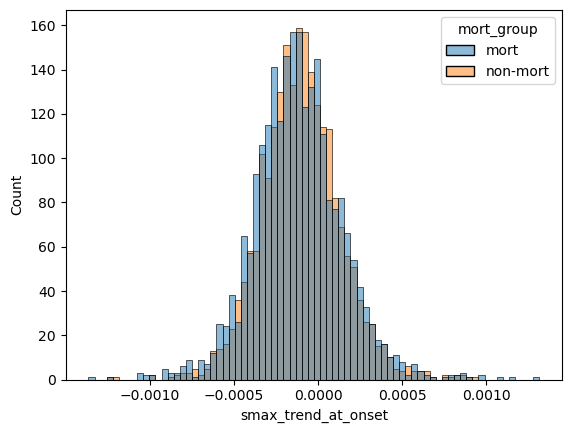

In [36]:
sns.histplot(
    ndvi_power_at_onset,
    x="smax_trend_at_onset",
    hue="mort_group"
)

In [37]:
mort_mask = ndvi_power_at_onset["mort_group"] == "mort"
smax_mort = ndvi_power_at_onset["smax_trend_at_onset"][mort_mask]
smax_nonmort = ndvi_power_at_onset["smax_trend_at_onset"][~mort_mask]

In [38]:
scipy.stats.ttest_ind(smax_mort, smax_nonmort, nan_policy="omit", alternative="less")

TtestResult(statistic=-2.3179238429213123, pvalue=0.01024841507981973, df=4630.0)

In [39]:
mort_mask = ndvi_power_at_onset["mort_group"] == "mort"
smax_mort = ndvi_power_at_onset["rel_smax_at_onset"][mort_mask]
smax_nonmort = ndvi_power_at_onset["rel_smax_at_onset"][~mort_mask]

In [40]:
scipy.stats.ttest_ind(smax_mort, smax_nonmort, nan_policy="omit", alternative="less")

TtestResult(statistic=-6.028380348014078, pvalue=8.761053306849114e-10, df=6148.0)

In [60]:
y = ndvi_power_at_onset["mort_group"] == "mort"
x = ndvi_power_at_onset[["rel_smax_at_onset"]]
mask = ~(x.isnull()).all(axis=1)

logreg = LogisticRegression()
logreg.fit(x[mask], y[mask])
print(x.shape[0])
print(f"Precision: {precision_score(y[mask], logreg.predict(x[mask])):.3f}")
print(f"Recall: {recall_score(y[mask], logreg.predict(x[mask])):.3f}")
print(f"AUC: {roc_auc_score(y[mask], logreg.predict(x[mask])):.3f}")

6150
Precision: 0.533
Recall: 0.658
AUC: 0.524


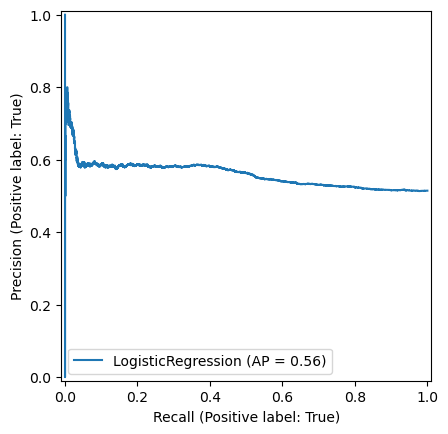

In [61]:
PrecisionRecallDisplay.from_estimator(logreg, x[mask], y[mask])

In [43]:
ndvi_power_at_onset.to_parquet("../data_working/power_at_onset_lcms.parquet")